
# RMSE comparison: blocked cross-validation vs final-block validation

This notebook does **not refit the LIM**. It reads the prediction netCDF files already produced by:

1. the moving 2–7-year blocked cross-validation experiment, and  
2. the final 2–7-year validation-block experiment.

For each design and window length, it calculates the RMSE of the centered 3-month PP forecasts.

Because PP in the state vector is standardized, RMSE is dimensionless and is expressed in units of the original PP standard deviation.

Plotting rules:

- Heatmap bullet: RMSE < 1.
- Global-map value: the latest **contiguously skillful** lead from lead 1 for which RMSE remains < 1.
- A separate `latest_any_lead_rmse_lt_1` diagnostic is also saved, in case isolated later leads below 1 are of interest.

The contiguous definition is used for the map because “the last month before RMSE exceeds 1” implies no re-entry after failure.


In [1]:

# ============================================================
# 0. Imports and settings
# ============================================================

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import date
from matplotlib.colors import BoundaryNorm, ListedColormap

import cartopy.crs as ccrs
import cartopy.feature as cfeature


# ------------------------------------------------------------
# Input files
# ------------------------------------------------------------

LIM_FILE = Path(
    "/nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/"
    "Cyclostationary_LIM_ORAS5_XRO10_GlobColour_"
    "PP_RECCAP2_all_regions_valid_zero30_1998_2025.nc"
)

SKILL_DIR = Path(
    "/nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/skill"
)

VALID_MASK_FILE = Path(
    "/nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/"
    "GlobColour_PP_grid_validity_RECCAP2_all_regions/"
    "valid_mask_zero30/"
    "RECCAP2_all_regions_valid_mask_zero30_on_PPgrid.nc"
)

WINDOW_YEARS = np.arange(2, 8, dtype=int)
TARGET_STATE = "PP"
RMSE_THRESHOLD = 1.0

EXCLUDE_REGIONS = [6, 18, 19, 29]
SAVE_FIGURES = False

CENTRAL_LONGITUDE = 210
PLOT_STRIDE = 4
DISPLAY_MAX_LEAD = 15

BASIN_ORDER = [
    "Pacific Ocean",
    "Indian Ocean",
    "Atlantic Ocean",
    "Southern Ocean",
    "Arctic Ocean",
]


def moving_cv_file(window_years):
    return SKILL_DIR / (
        "Cyclostationary_LIM_MATLABstyle_CSWhite_PP_forecast_skill_23month_"
        f"3month_running_mean_leave{window_years}yearblockout_"
        "corr_threshold05_RECCAP2_all_regions_valid_zero30.nc"
    )


def last_block_file(window_years):
    return SKILL_DIR / (
        "Cyclostationary_LIM_MATLABstyle_CSWhite_PP_forecast_skill_23month_"
        f"3month_running_mean_last{window_years}yearblock_"
        "corr_threshold05_RECCAP2_all_regions_valid_zero30.nc"
    )


def rmse_output_file(design, window_years):
    return SKILL_DIR / (
        "Cyclostationary_LIM_MATLABstyle_CSWhite_PP_RMSE_23month_"
        f"3month_running_mean_{design}_{window_years}year_"
        "RECCAP2_all_regions_valid_zero30.nc"
    )


FIG_DIR = SKILL_DIR / "RMSE_windowCV_vs_lastblock"
FIG_DIR.mkdir(parents=True, exist_ok=True)


In [2]:

# ============================================================
# 1. Helper functions
# ============================================================

def decode_strings(values):
    values = np.asarray(values)
    if values.dtype.kind in {"S", "O"}:
        return np.asarray([
            v.decode() if isinstance(v, (bytes, np.bytes_)) else str(v)
            for v in values
        ], dtype=object)
    return values.astype(str)


def centered_mean_3_timeseries(x):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)

    if x.size < 3:
        return out

    stacked = np.vstack([x[:-2], x[1:-1], x[2:]])
    valid = np.all(np.isfinite(stacked), axis=0)
    out[1:-1][valid] = np.mean(stacked[:, valid], axis=0)
    return out


def rmse_1d(forecast, observation):
    forecast = np.asarray(forecast, dtype=float)
    observation = np.asarray(observation, dtype=float)

    ok = np.isfinite(forecast) & np.isfinite(observation)
    if ok.sum() == 0:
        return np.nan

    return float(np.sqrt(np.mean((forecast[ok] - observation[ok]) ** 2)))


def latest_any_below(values, threshold=1.0):
    values = np.asarray(values, dtype=float)
    idx = np.where(np.isfinite(values) & (values < threshold))[0]
    return int(idx[-1] + 1) if idx.size else 0


def latest_contiguous_below(values, threshold=1.0):
    """
    Latest lead in the uninterrupted sequence starting at lead 1
    for which RMSE < threshold.

    Examples
    --------
    [0.7, 0.8, 1.1, 0.9] -> 2
    [1.2, 0.8, 0.7]      -> 0
    [0.7, 0.8, 0.9]      -> 3
    """
    values = np.asarray(values, dtype=float)

    latest = 0
    for i, value in enumerate(values):
        if not np.isfinite(value) or value >= threshold:
            break
        latest = i + 1

    return latest


def get_basin_name(ds, region):
    if "basin" not in ds:
        return ""
    value = ds["basin"].sel(region=region).values
    if isinstance(value, (bytes, np.bytes_)):
        return value.decode()
    return str(value)


def get_region_label(ds, region, short=True):
    if "region_name" in ds:
        value = ds["region_name"].sel(region=region).values
        if isinstance(value, (bytes, np.bytes_)):
            value = value.decode()
        value = str(value)
        return f"R{int(region)}" if short else f"R{int(region)}: {value}"
    return f"R{int(region)}"


def add_cyclic_manual(data, lon):
    data = np.asarray(data)
    lon = np.asarray(lon)

    dlon = float(np.nanmedian(np.diff(lon)))
    lon_cyclic = np.concatenate([lon, [lon[-1] + dlon]])
    data_cyclic = np.concatenate([data, data[:, :1]], axis=1)

    return data_cyclic, lon_cyclic


def lon_to_180(lon):
    return ((float(lon) + 180.0) % 360.0) - 180.0


def weighted_centroid(lon, lat, region_mask):
    lon2d, lat2d = np.meshgrid(lon, lat)
    ok = np.asarray(region_mask, dtype=bool)

    if not np.any(ok):
        return np.nan, np.nan

    weights = np.cos(np.deg2rad(lat2d[ok]))
    lat_c = np.average(lat2d[ok], weights=weights)

    lon_rad = np.deg2rad(lon2d[ok])
    x = np.average(np.cos(lon_rad), weights=weights)
    y = np.average(np.sin(lon_rad), weights=weights)
    lon_c = np.rad2deg(np.arctan2(y, x)) % 360.0

    return lon_c, lat_c


In [3]:

# ============================================================
# 2. Load observations
# ============================================================

if not LIM_FILE.exists():
    raise FileNotFoundError(f"LIM input file not found:\n{LIM_FILE}")

with xr.open_dataset(LIM_FILE) as ds:
    ds_lim = ds.load()

state_vector = ds_lim["state_vector"].transpose("region", "time", "state")
regions = state_vector.region.values.astype(np.int16)
times = state_vector.time.values
states = decode_strings(state_vector.state.values)

match = np.where(states == TARGET_STATE)[0]
if match.size != 1:
    raise ValueError(f"TARGET_STATE={TARGET_STATE!r} not unique: {list(states)}")

target_idx = int(match[0])

# Centered 3-month observed PP for every region and target time.
obs_pp_3mon = np.full(
    (len(regions), len(times)),
    np.nan,
    dtype=np.float32,
)

for ir, reg in enumerate(regions):
    raw_pp = (
        state_vector
        .sel(region=reg)
        .values[:, target_idx]
        .astype(float)
    )
    obs_pp_3mon[ir] = centered_mean_3_timeseries(raw_pp).astype(np.float32)

obs_pp_3mon = xr.DataArray(
    obs_pp_3mon,
    dims=("region", "time"),
    coords={"region": regions, "time": times},
    name="PP_observation_3month_centered",
)


In [4]:

# ============================================================
# 3. Calculate RMSE from saved predictions
# ============================================================

designs = {
    "moving_cv": moving_cv_file,
    "last_block": last_block_file,
}

rmse_datasets = {
    "moving_cv": {},
    "last_block": {},
}


for design, file_function in designs.items():
    print("\n" + "=" * 80)
    print(f"Design: {design}")
    print("=" * 80)

    for window_years in WINDOW_YEARS:
        window_years = int(window_years)
        input_file = file_function(window_years)

        if not input_file.exists():
            raise FileNotFoundError(
                f"Prediction file not found for {design}, {window_years} years:\n"
                f"{input_file}"
            )

        with xr.open_dataset(input_file) as ds:
            ds_pred = ds.load()

        prediction = ds_pred["PP_prediction"].transpose(
            "region",
            "init_time",
            "lead",
        )

        if not np.array_equal(
            pd.to_datetime(prediction.init_time.values),
            pd.to_datetime(times),
        ):
            raise ValueError(
                f"init_time mismatch in:\n{input_file}"
            )

        leads = prediction.lead.values.astype(np.int16)
        n_region = prediction.sizes["region"]
        n_lead = prediction.sizes["lead"]

        rmse = np.full(
            (n_region, n_lead),
            np.nan,
            dtype=np.float32,
        )
        n_pairs = np.zeros(
            (n_region, n_lead),
            dtype=np.int16,
        )

        rmse_by_init_month = np.full(
            (n_region, 12, n_lead),
            np.nan,
            dtype=np.float32,
        )
        n_pairs_by_init_month = np.zeros(
            (n_region, 12, n_lead),
            dtype=np.int16,
        )

        init_months = pd.DatetimeIndex(
            pd.to_datetime(prediction.init_time.values)
        ).month.values

        for ir, reg in enumerate(prediction.region.values):
            obs_region = obs_pp_3mon.sel(region=reg).values.astype(float)

            for il, lead in enumerate(leads):
                init_indices = np.arange(prediction.sizes["init_time"])
                target_indices = init_indices + int(lead)

                in_range = target_indices < len(times)
                init_indices = init_indices[in_range]
                target_indices = target_indices[in_range]

                pred = prediction.sel(region=reg).values[
                    init_indices,
                    il,
                ].astype(float)
                obs = obs_region[target_indices]

                ok = np.isfinite(pred) & np.isfinite(obs)
                n_pairs[ir, il] = int(ok.sum())
                rmse[ir, il] = rmse_1d(pred, obs)

                for month in range(1, 13):
                    choose = init_months[init_indices] == month
                    pred_m = pred[choose]
                    obs_m = obs[choose]

                    ok_m = np.isfinite(pred_m) & np.isfinite(obs_m)
                    n_pairs_by_init_month[
                        ir,
                        month - 1,
                        il,
                    ] = int(ok_m.sum())
                    rmse_by_init_month[
                        ir,
                        month - 1,
                        il,
                    ] = rmse_1d(pred_m, obs_m)

        latest_contiguous = np.array(
            [
                latest_contiguous_below(
                    rmse[ir],
                    RMSE_THRESHOLD,
                )
                for ir in range(n_region)
            ],
            dtype=np.int16,
        )

        latest_any = np.array(
            [
                latest_any_below(
                    rmse[ir],
                    RMSE_THRESHOLD,
                )
                for ir in range(n_region)
            ],
            dtype=np.int16,
        )

        latest_contiguous_by_month = np.zeros(
            (n_region, 12),
            dtype=np.int16,
        )
        latest_any_by_month = np.zeros(
            (n_region, 12),
            dtype=np.int16,
        )

        for ir in range(n_region):
            for im in range(12):
                latest_contiguous_by_month[ir, im] = latest_contiguous_below(
                    rmse_by_init_month[ir, im],
                    RMSE_THRESHOLD,
                )
                latest_any_by_month[ir, im] = latest_any_below(
                    rmse_by_init_month[ir, im],
                    RMSE_THRESHOLD,
                )

        data_vars = {
            "PP_RMSE": (
                ("region", "lead"),
                rmse,
                {
                    "long_name": (
                        "RMSE of centered 3-month standardized PP forecast"
                    ),
                    "units": (
                        "standard deviation of standardized PP"
                    ),
                },
            ),
            "PP_RMSE_by_init_month": (
                ("region", "init_month", "lead"),
                rmse_by_init_month,
            ),
            "n_pairs": (
                ("region", "lead"),
                n_pairs,
            ),
            "n_pairs_by_init_month": (
                ("region", "init_month", "lead"),
                n_pairs_by_init_month,
            ),
            "latest_contiguous_lead_rmse_lt_1": (
                ("region",),
                latest_contiguous,
                {
                    "long_name": (
                        "Last consecutive lead from lead 1 with RMSE below 1"
                    ),
                    "units": "month",
                },
            ),
            "latest_any_lead_rmse_lt_1": (
                ("region",),
                latest_any,
                {
                    "long_name": (
                        "Latest lead anywhere with RMSE below 1"
                    ),
                    "units": "month",
                },
            ),
            "latest_contiguous_lead_rmse_lt_1_by_init_month": (
                ("region", "init_month"),
                latest_contiguous_by_month,
            ),
            "latest_any_lead_rmse_lt_1_by_init_month": (
                ("region", "init_month"),
                latest_any_by_month,
            ),
        }

        for optional_name in [
            "region_name",
            "basin",
            "original_region_id",
        ]:
            if optional_name in ds_pred:
                data_vars[optional_name] = ds_pred[optional_name]

        ds_rmse = xr.Dataset(
            data_vars=data_vars,
            coords={
                "region": prediction.region.values,
                "lead": leads,
                "init_month": np.arange(1, 13, dtype=np.int16),
            },
            attrs={
                "title": (
                    "RMSE of MATLAB-style CS-White LIM PP forecasts"
                ),
                "prediction_source_file": str(input_file),
                "state_vector_source_file": str(LIM_FILE),
                "validation_design": design,
                "window_years": window_years,
                "rmse_threshold": RMSE_THRESHOLD,
                "latest_lead_definition_for_map": (
                    "Latest uninterrupted lead starting from lead 1 "
                    "for which RMSE remains below 1."
                ),
                "date_created": date.today().isoformat(),
            },
        )

        output_file = rmse_output_file(design, window_years)
        if output_file.exists():
            output_file.unlink()

        ds_rmse.to_netcdf(output_file)
        rmse_datasets[design][window_years] = ds_rmse

        print(
            f"{window_years} years: saved {output_file.name}; "
            f"n_pairs={int(np.nanmin(n_pairs))}–{int(np.nanmax(n_pairs))}"
        )



Design: moving_cv
2 years: saved Cyclostationary_LIM_MATLABstyle_CSWhite_PP_RMSE_23month_3month_running_mean_moving_cv_2year_RECCAP2_all_regions_valid_zero30.nc; n_pairs=312–334
3 years: saved Cyclostationary_LIM_MATLABstyle_CSWhite_PP_RMSE_23month_3month_running_mean_moving_cv_3year_RECCAP2_all_regions_valid_zero30.nc; n_pairs=312–334
4 years: saved Cyclostationary_LIM_MATLABstyle_CSWhite_PP_RMSE_23month_3month_running_mean_moving_cv_4year_RECCAP2_all_regions_valid_zero30.nc; n_pairs=312–334
5 years: saved Cyclostationary_LIM_MATLABstyle_CSWhite_PP_RMSE_23month_3month_running_mean_moving_cv_5year_RECCAP2_all_regions_valid_zero30.nc; n_pairs=312–334
6 years: saved Cyclostationary_LIM_MATLABstyle_CSWhite_PP_RMSE_23month_3month_running_mean_moving_cv_6year_RECCAP2_all_regions_valid_zero30.nc; n_pairs=312–334
7 years: saved Cyclostationary_LIM_MATLABstyle_CSWhite_PP_RMSE_23month_3month_running_mean_moving_cv_7year_RECCAP2_all_regions_valid_zero30.nc; n_pairs=312–334

Design: last_block
2

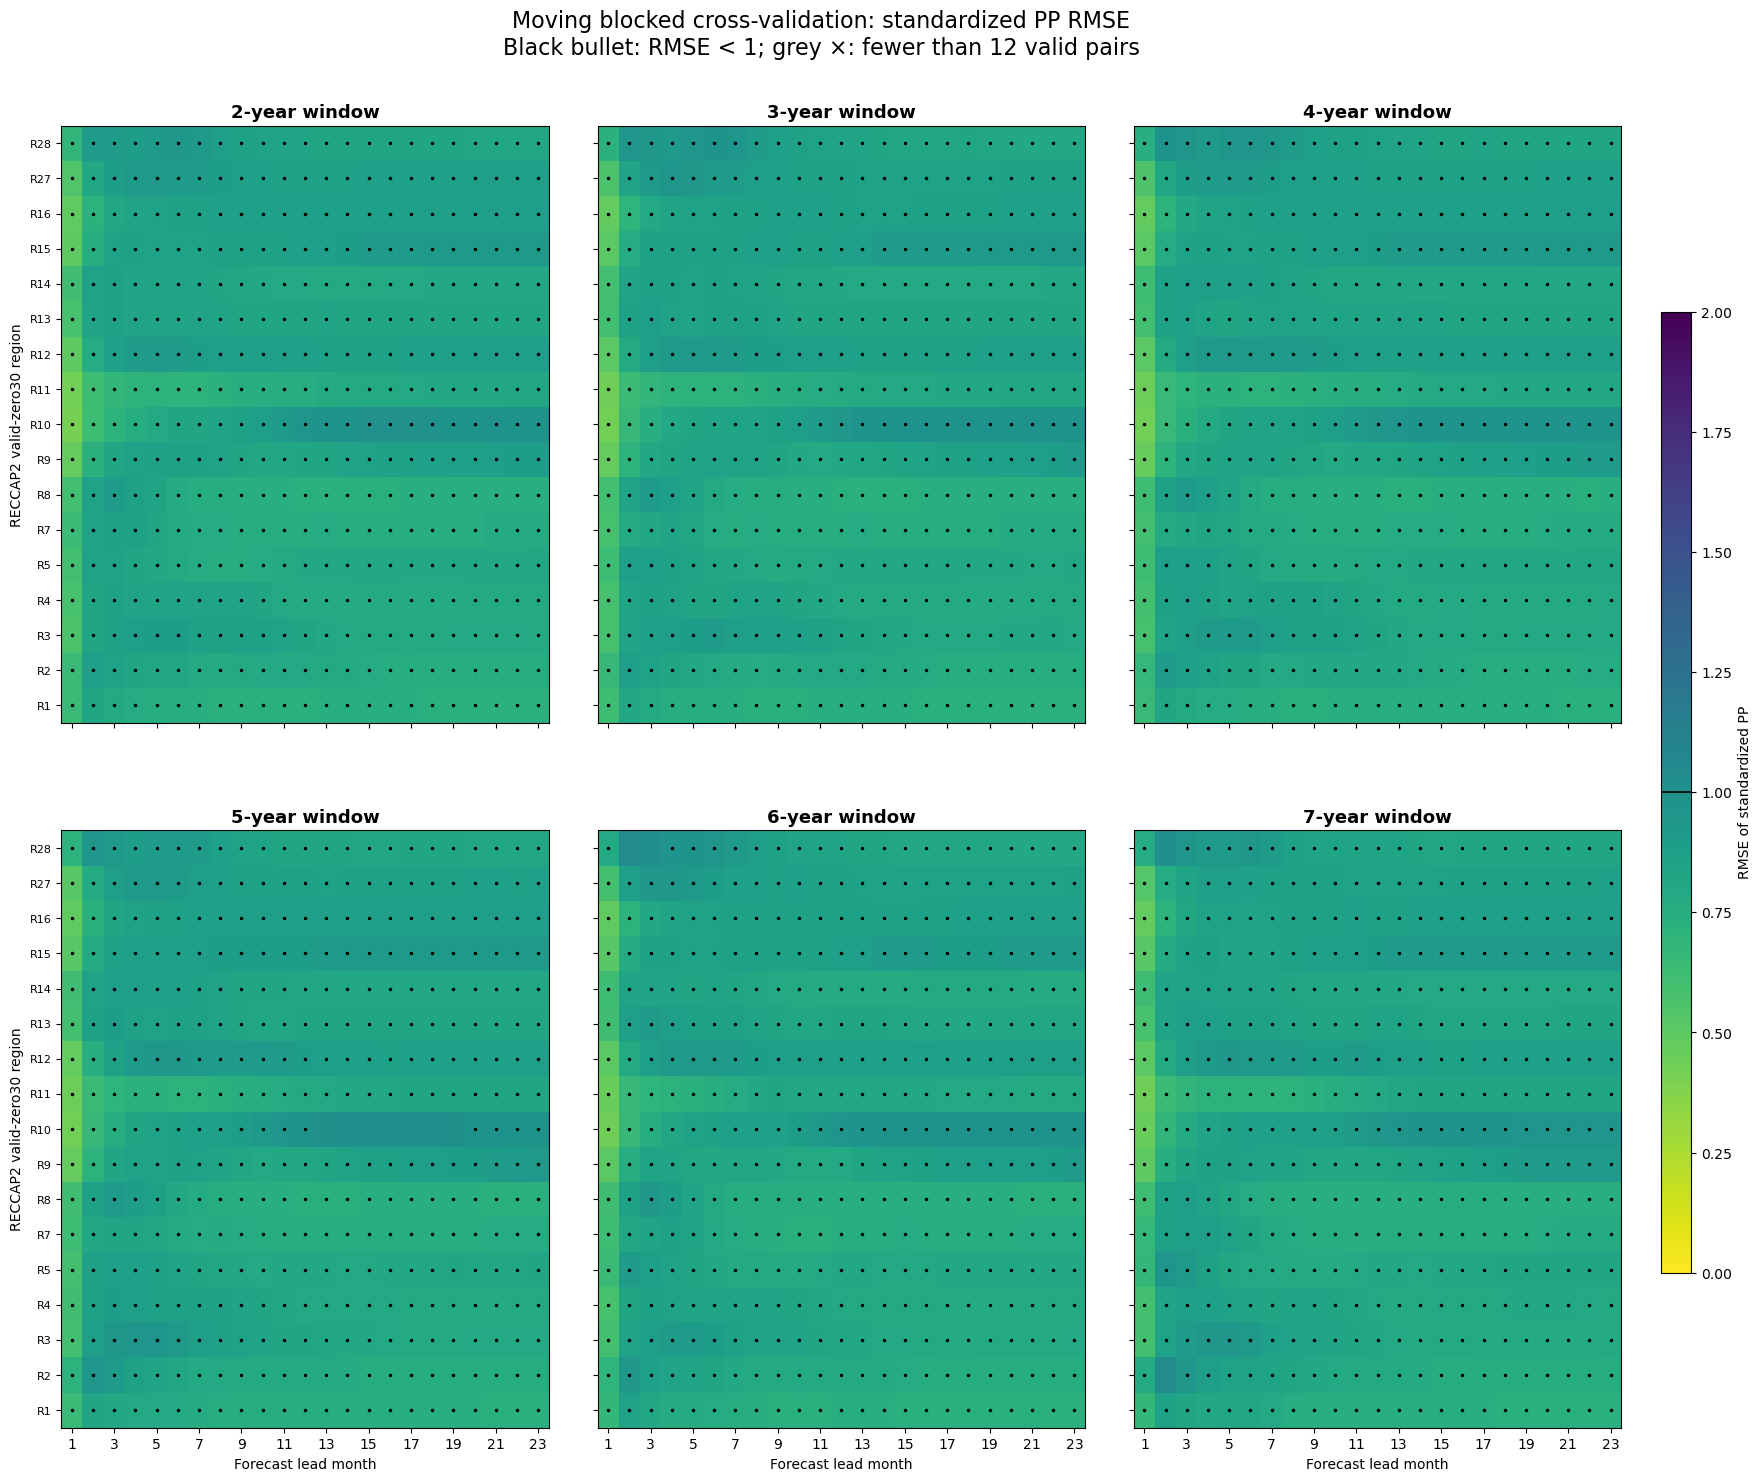

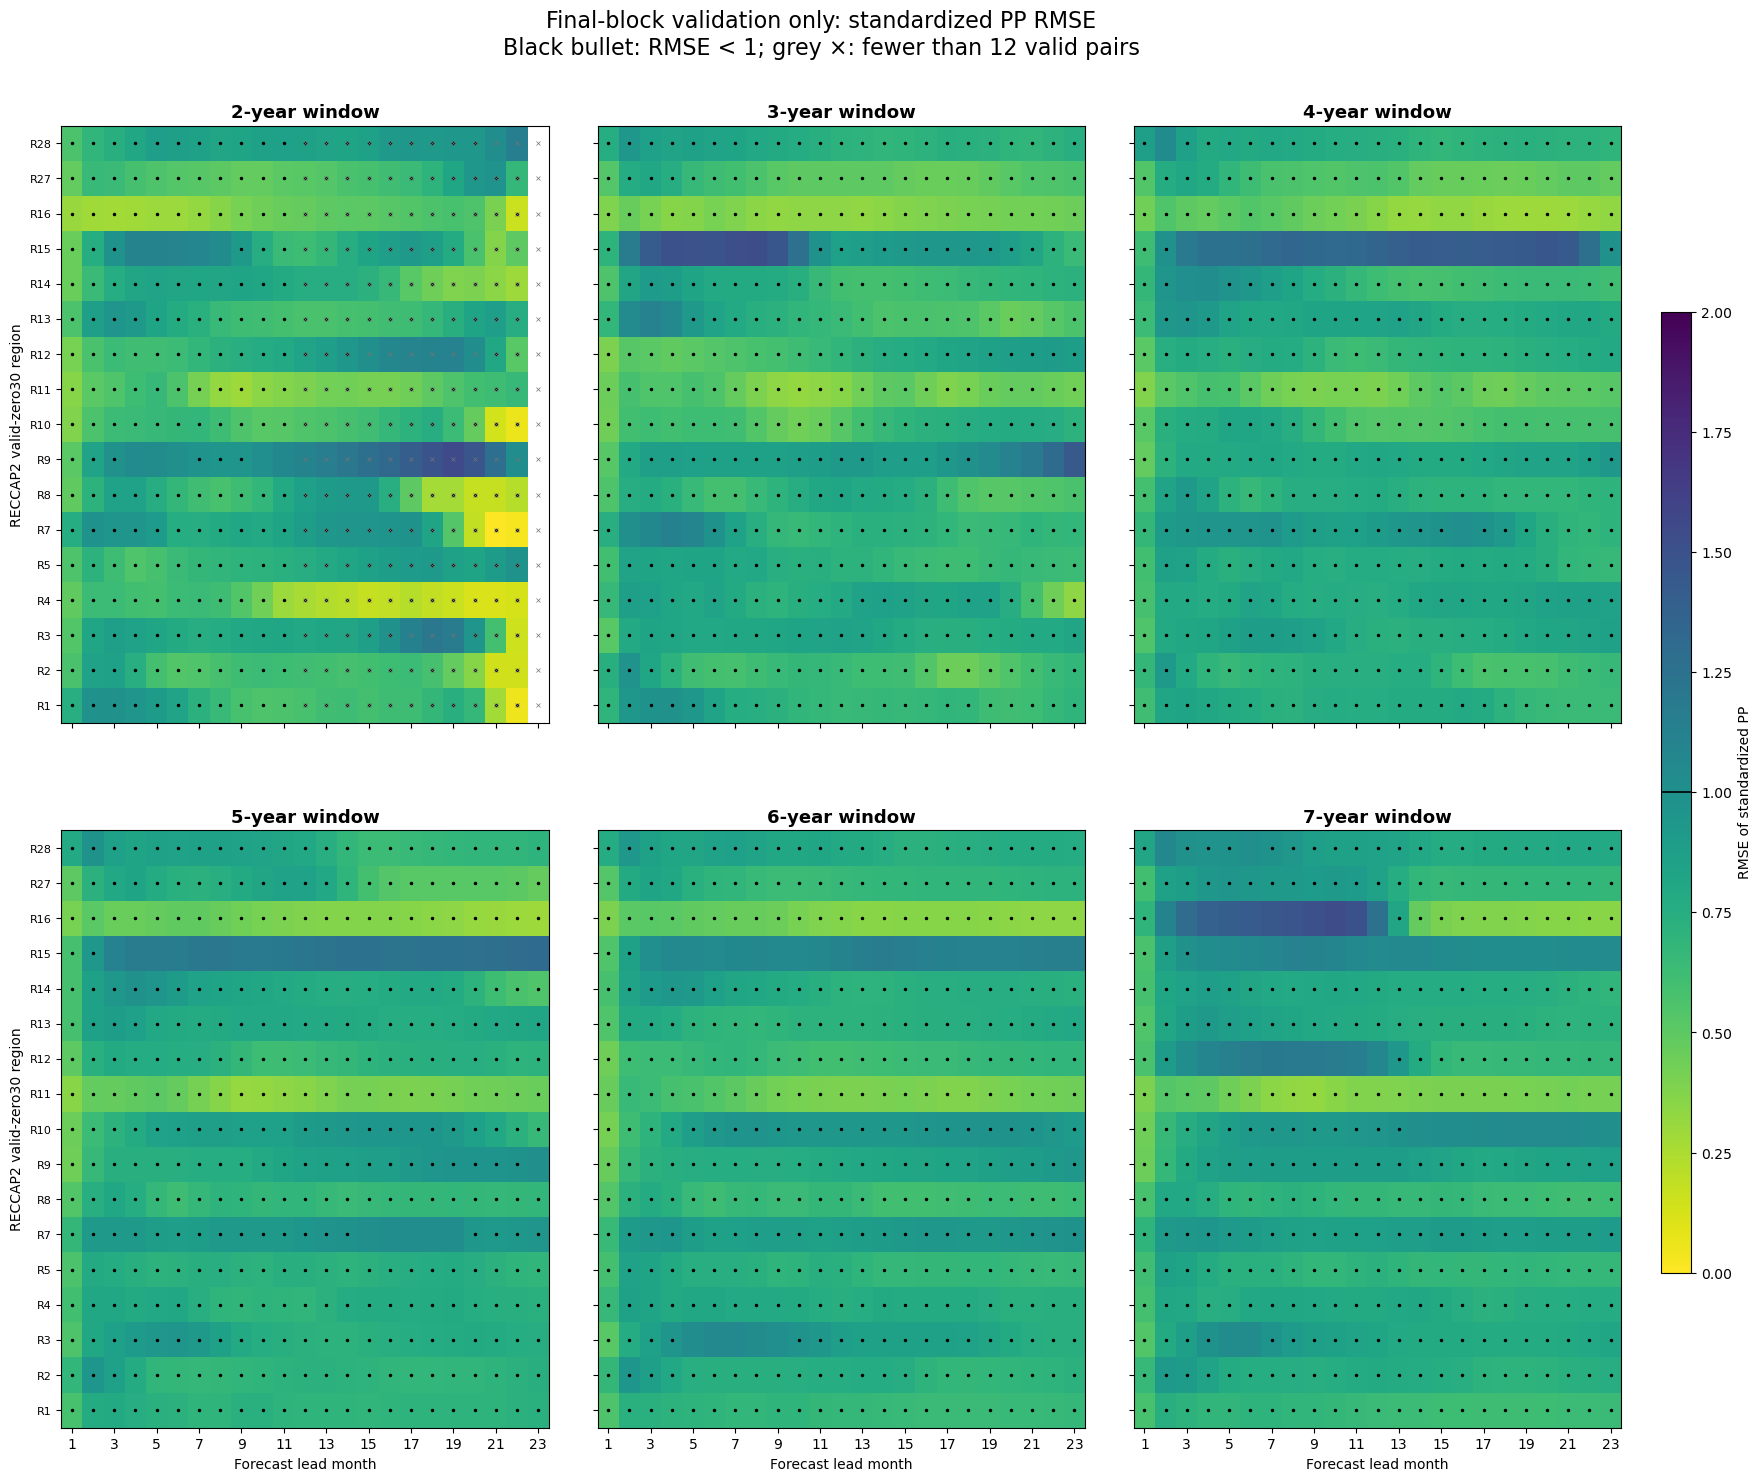

In [5]:

# ============================================================
# 4. Heatmaps: moving blocked CV and final-block validation
# ============================================================

reference_ds = rmse_datasets["moving_cv"][int(WINDOW_YEARS[0])]

keep_regions = [
    int(reg)
    for reg in reference_ds.region.values
    if int(reg) not in EXCLUDE_REGIONS
]

region_basin = {
    int(reg): get_basin_name(reference_ds, reg)
    for reg in keep_regions
}
basin_rank = {
    name: i
    for i, name in enumerate(BASIN_ORDER)
}

regions_plot = np.array(
    sorted(
        keep_regions,
        key=lambda reg: (
            basin_rank.get(
                region_basin[reg],
                len(BASIN_ORDER),
            ),
            reg,
        ),
    ),
    dtype=np.int16,
)

n_region_plot = len(regions_plot)
leads = reference_ds.lead.values.astype(np.int16)

basin_groups = []
for basin_name in BASIN_ORDER:
    idx = [
        i
        for i, reg in enumerate(regions_plot)
        if region_basin[int(reg)] == basin_name
    ]
    if idx:
        basin_groups.append({
            "name": basin_name,
            "start": min(idx),
            "end": max(idx),
        })


for design, design_title in [
    ("moving_cv", "Moving blocked cross-validation"),
    ("last_block", "Final-block validation only"),
]:
    fig, axes = plt.subplots(
        2,
        3,
        figsize=(20, 0.50 * n_region_plot + 7.0),
        sharex=True,
        sharey=True,
    )
    axes = axes.ravel()

    last_im = None

    for ax, window_years in zip(axes, WINDOW_YEARS):
        window_years = int(window_years)
        ds_this = rmse_datasets[design][window_years]

        z = ds_this["PP_RMSE"].sel(region=regions_plot)
        n = ds_this["n_pairs"].sel(region=regions_plot)

        y_edges = np.arange(n_region_plot + 1)
        x_edges = np.arange(
            leads[0] - 0.5,
            leads[-1] + 1.5,
            1.0,
        )

        last_im = ax.pcolormesh(
            x_edges,
            y_edges,
            z.values,
            vmin=0,
            vmax=2,
            cmap="viridis_r",
            shading="auto",
        )

        # Bullet for RMSE < 1.
        yy, xx = np.where(
            np.isfinite(z.values)
            & (z.values < RMSE_THRESHOLD)
        )
        ax.plot(
            leads[xx],
            yy + 0.5,
            "k.",
            markersize=3.0,
        )

        # Cross where sample size is small.
        yy_small, xx_small = np.where(n.values < 12)
        ax.plot(
            leads[xx_small],
            yy_small + 0.5,
            "x",
            color="0.45",
            markersize=2.5,
            markeredgewidth=0.5,
        )

        for group in basin_groups[:-1]:
            ax.axhline(
                group["end"] + 1,
                color="k",
                lw=1.1,
            )

        ax.set_title(
            f"{window_years}-year window",
            fontsize=13,
            fontweight="bold",
        )
        ax.set_xlim(
            leads[0] - 0.5,
            leads[-1] + 0.5,
        )
        ax.set_ylim(0, n_region_plot)
        ax.set_xticks(
            np.arange(leads[0], leads[-1] + 1, 2)
        )

    for ax in axes[3:]:
        ax.set_xlabel("Forecast lead month")

    for ax in axes[::3]:
        ax.set_ylabel("RECCAP2 valid-zero30 region")
        ax.set_yticks(np.arange(n_region_plot) + 0.5)
        ax.set_yticklabels(
            [
                get_region_label(reference_ds, reg, short=True)
                for reg in regions_plot
            ],
            fontsize=8,
        )

    fig.suptitle(
        f"{design_title}: standardized PP RMSE\n"
        "Black bullet: RMSE < 1; grey ×: fewer than 12 valid pairs",
        fontsize=16,
        y=0.995,
    )

    fig.subplots_adjust(
        left=0.12,
        right=0.90,
        top=0.92,
        bottom=0.08,
        wspace=0.10,
        hspace=0.18,
    )

    cax = fig.add_axes([0.92, 0.18, 0.015, 0.62])
    cbar = fig.colorbar(last_im, cax=cax)
    cbar.set_label("RMSE of standardized PP")
    cbar.ax.axhline(
        RMSE_THRESHOLD,
        color="k",
        lw=1.2,
    )

    if SAVE_FIGURES:
        fig.savefig(
            FIG_DIR / f"RMSE_heatmap_{design}_2to7year.png",
            dpi=200,
            bbox_inches="tight",
        )

    plt.show()


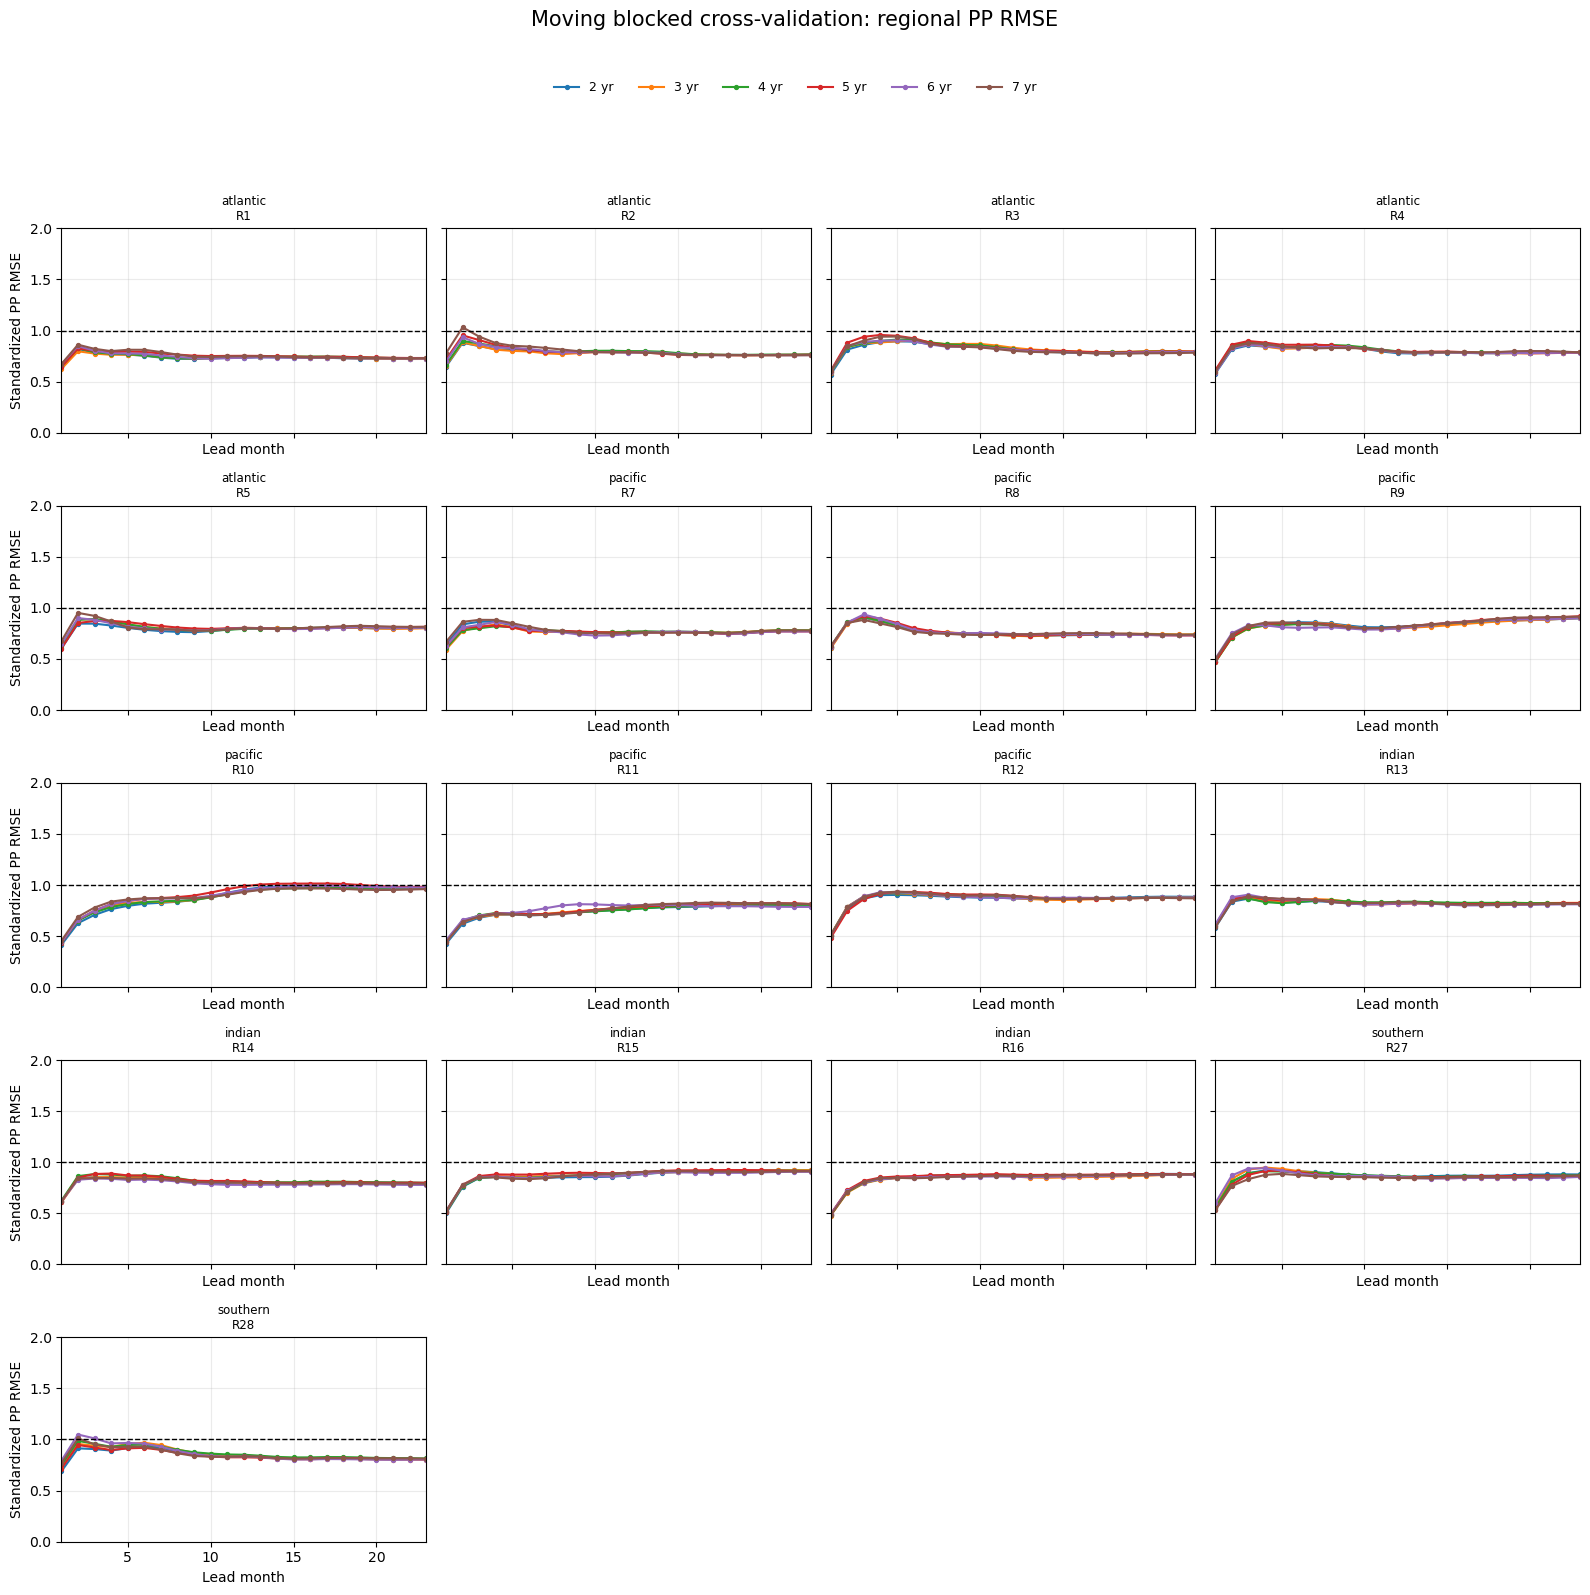

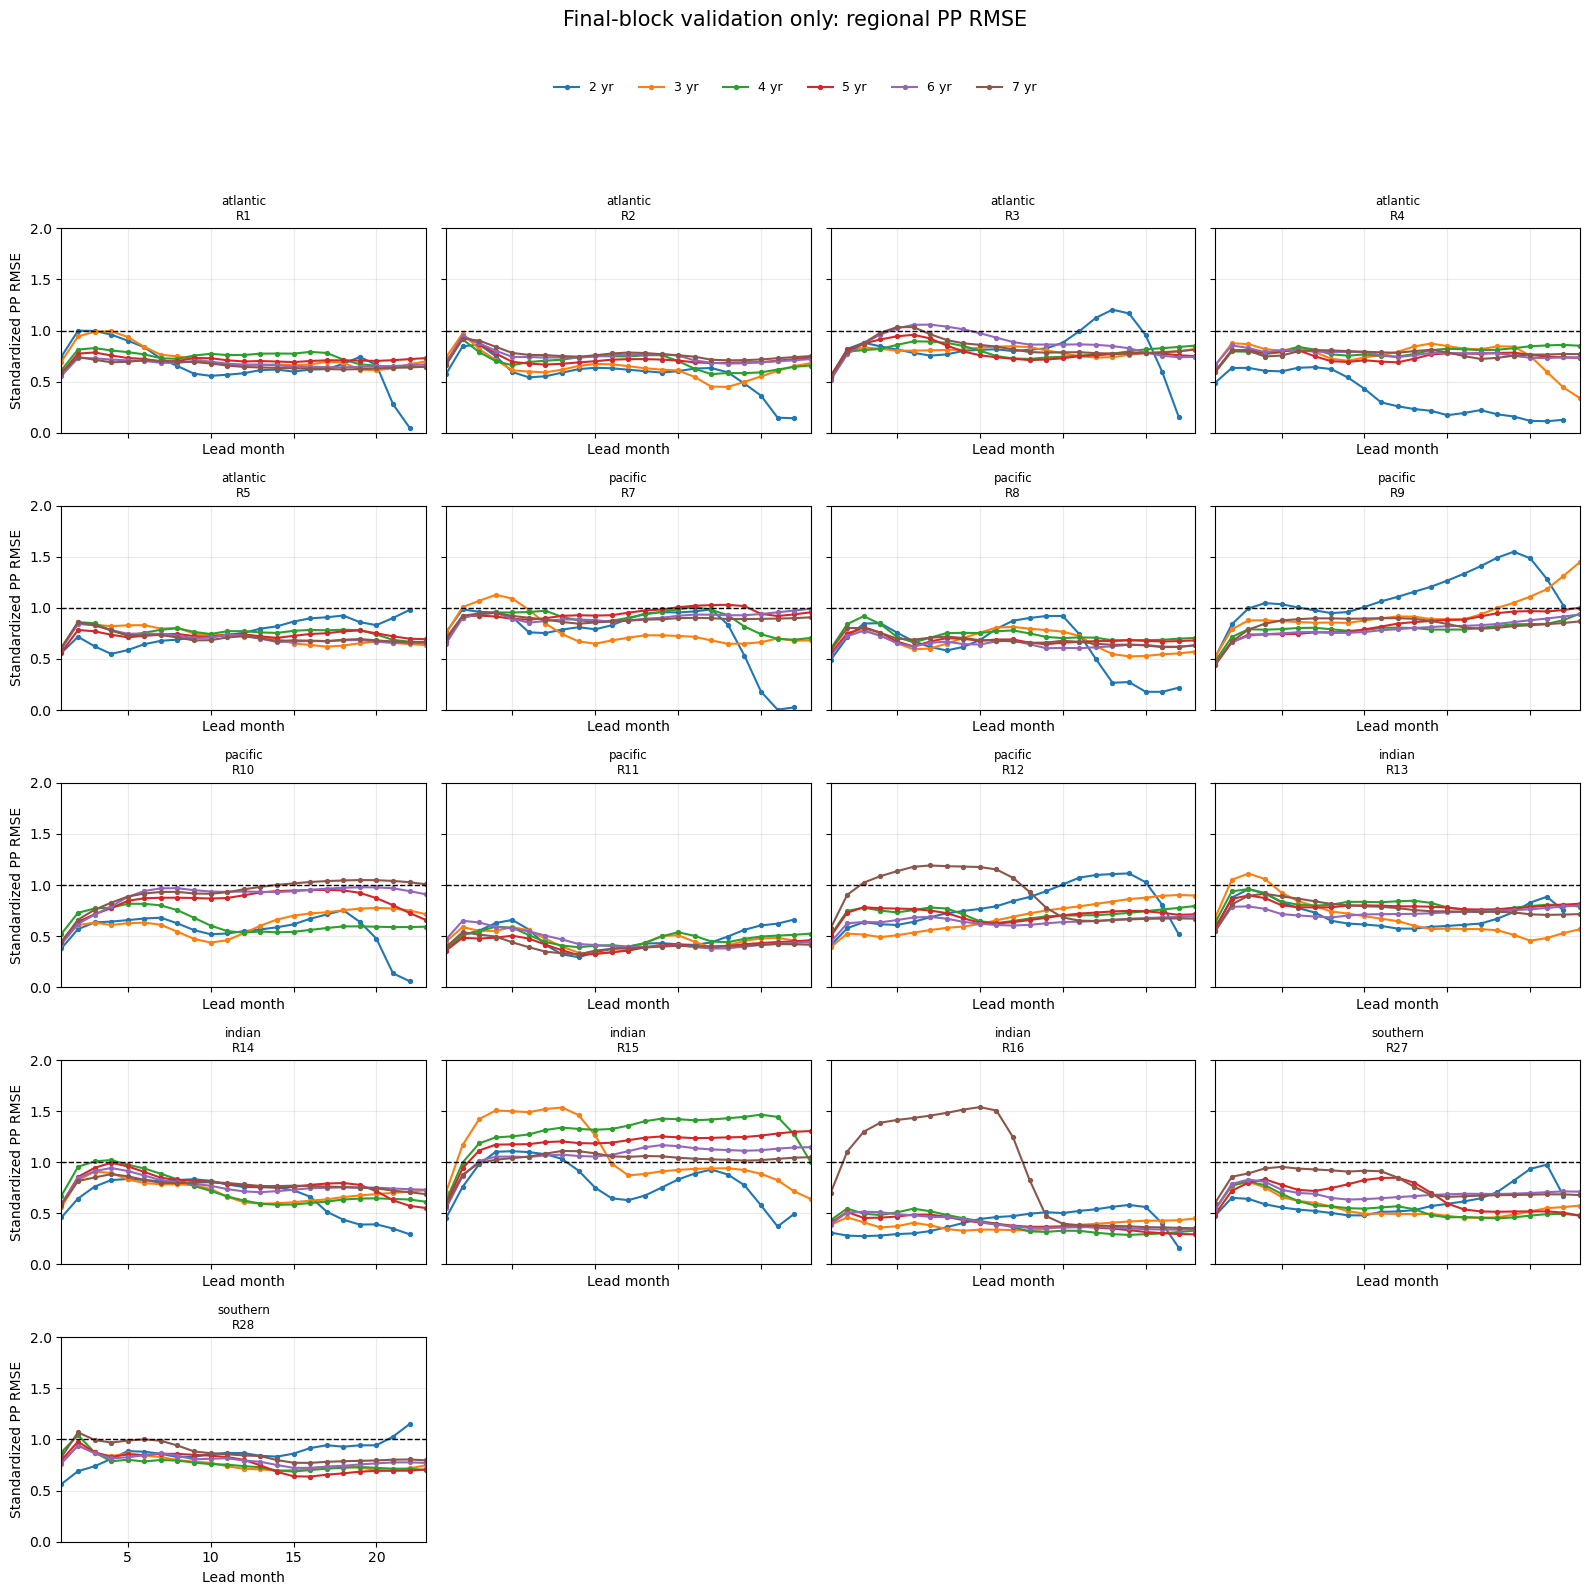

In [6]:

# ============================================================
# 5. Regional RMSE curves
# ============================================================

for design, design_title in [
    ("moving_cv", "Moving blocked cross-validation"),
    ("last_block", "Final-block validation only"),
]:
    ncol = 4
    nrow = int(np.ceil(n_region_plot / ncol))

    fig, axes = plt.subplots(
        nrow,
        ncol,
        figsize=(16, 3.0 * nrow),
        sharex=True,
        sharey=True,
    )
    axes = np.asarray(axes).ravel()

    for ax, reg in zip(axes, regions_plot):
        for window_years in WINDOW_YEARS:
            window_years = int(window_years)
            ds_this = rmse_datasets[design][window_years]

            z = ds_this["PP_RMSE"].sel(region=reg)

            ax.plot(
                leads,
                z.values,
                marker="o",
                ms=2.8,
                lw=1.5,
                label=f"{window_years} yr",
            )

        ax.axhline(
            RMSE_THRESHOLD,
            color="k",
            lw=1.0,
            ls="--",
        )
        ax.set_title(
            f"{region_basin[int(reg)]}\n"
            f"{get_region_label(reference_ds, reg, short=True)}",
            fontsize=8.5,
        )
        ax.set_xlim(leads[0], leads[-1])
        ax.set_ylim(0, 2)
        ax.grid(alpha=0.25)

    for ax in axes[n_region_plot:]:
        ax.axis("off")

    for i, ax in enumerate(axes[:n_region_plot]):
        ax.set_xlabel("Lead month")
        if i % ncol == 0:
            ax.set_ylabel("Standardized PP RMSE")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=6,
        frameon=False,
        fontsize=9,
    )

    fig.suptitle(
        f"{design_title}: regional PP RMSE",
        fontsize=15,
        y=1.06,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    if SAVE_FIGURES:
        fig.savefig(
            FIG_DIR / f"RMSE_regional_lines_{design}_2to7year.png",
            dpi=200,
            bbox_inches="tight",
        )

    plt.show()


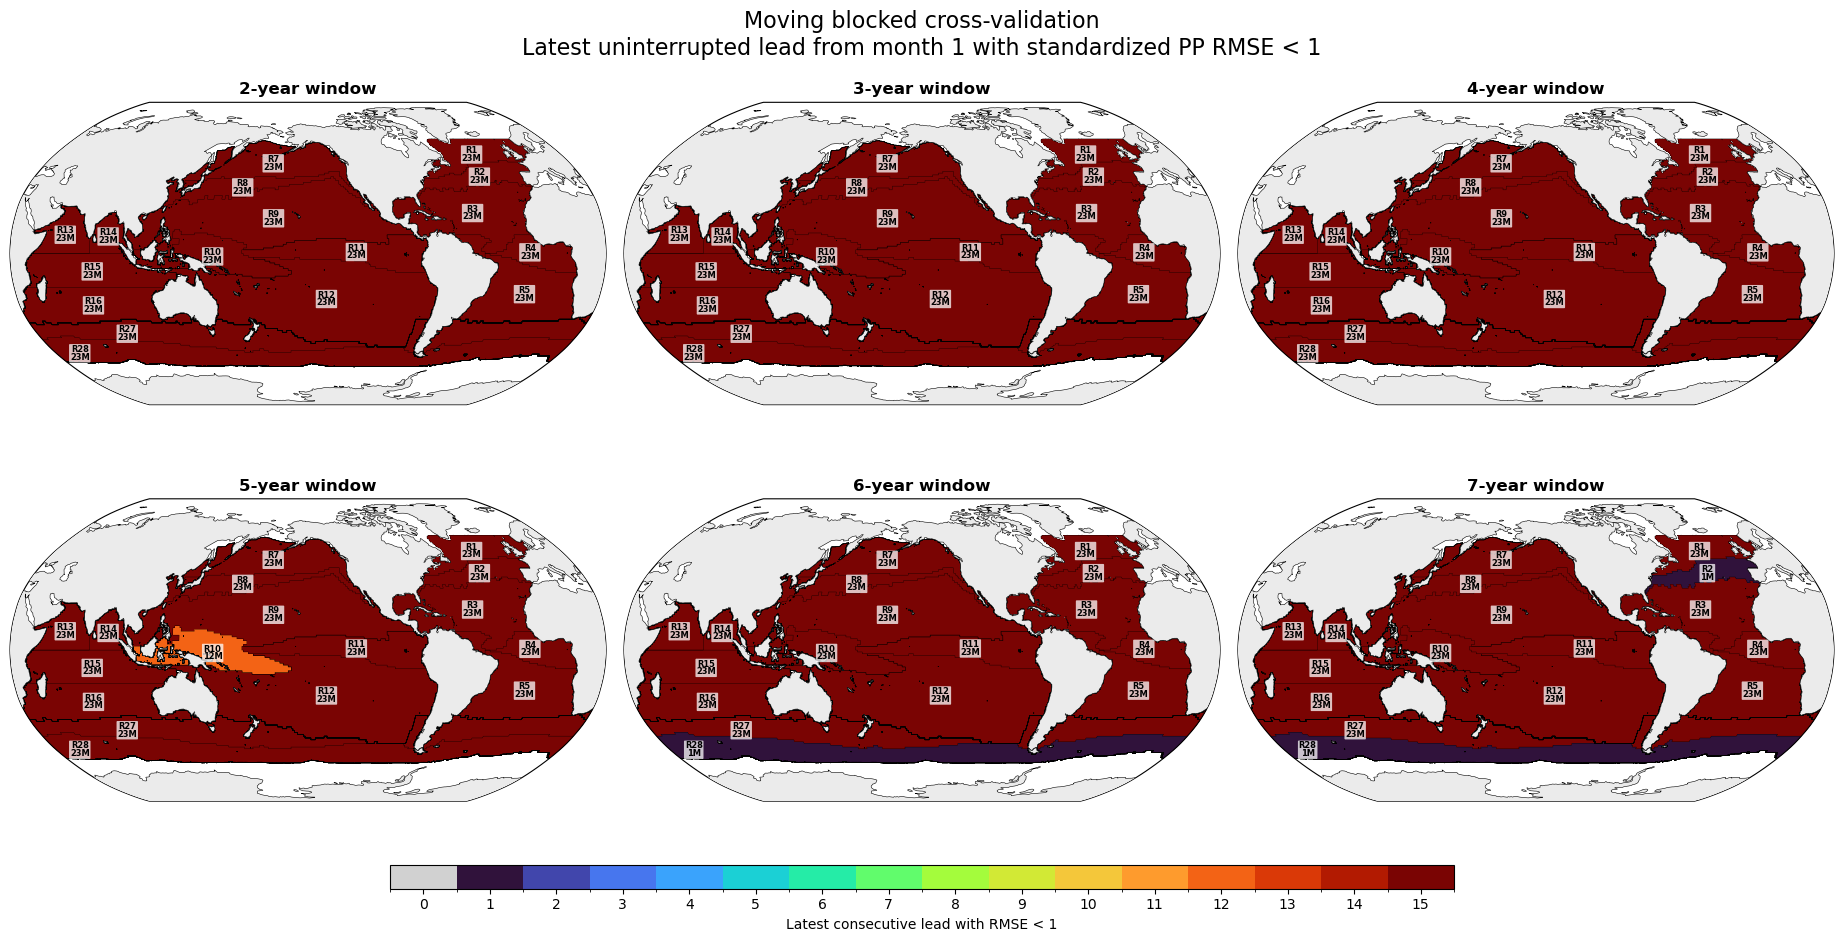

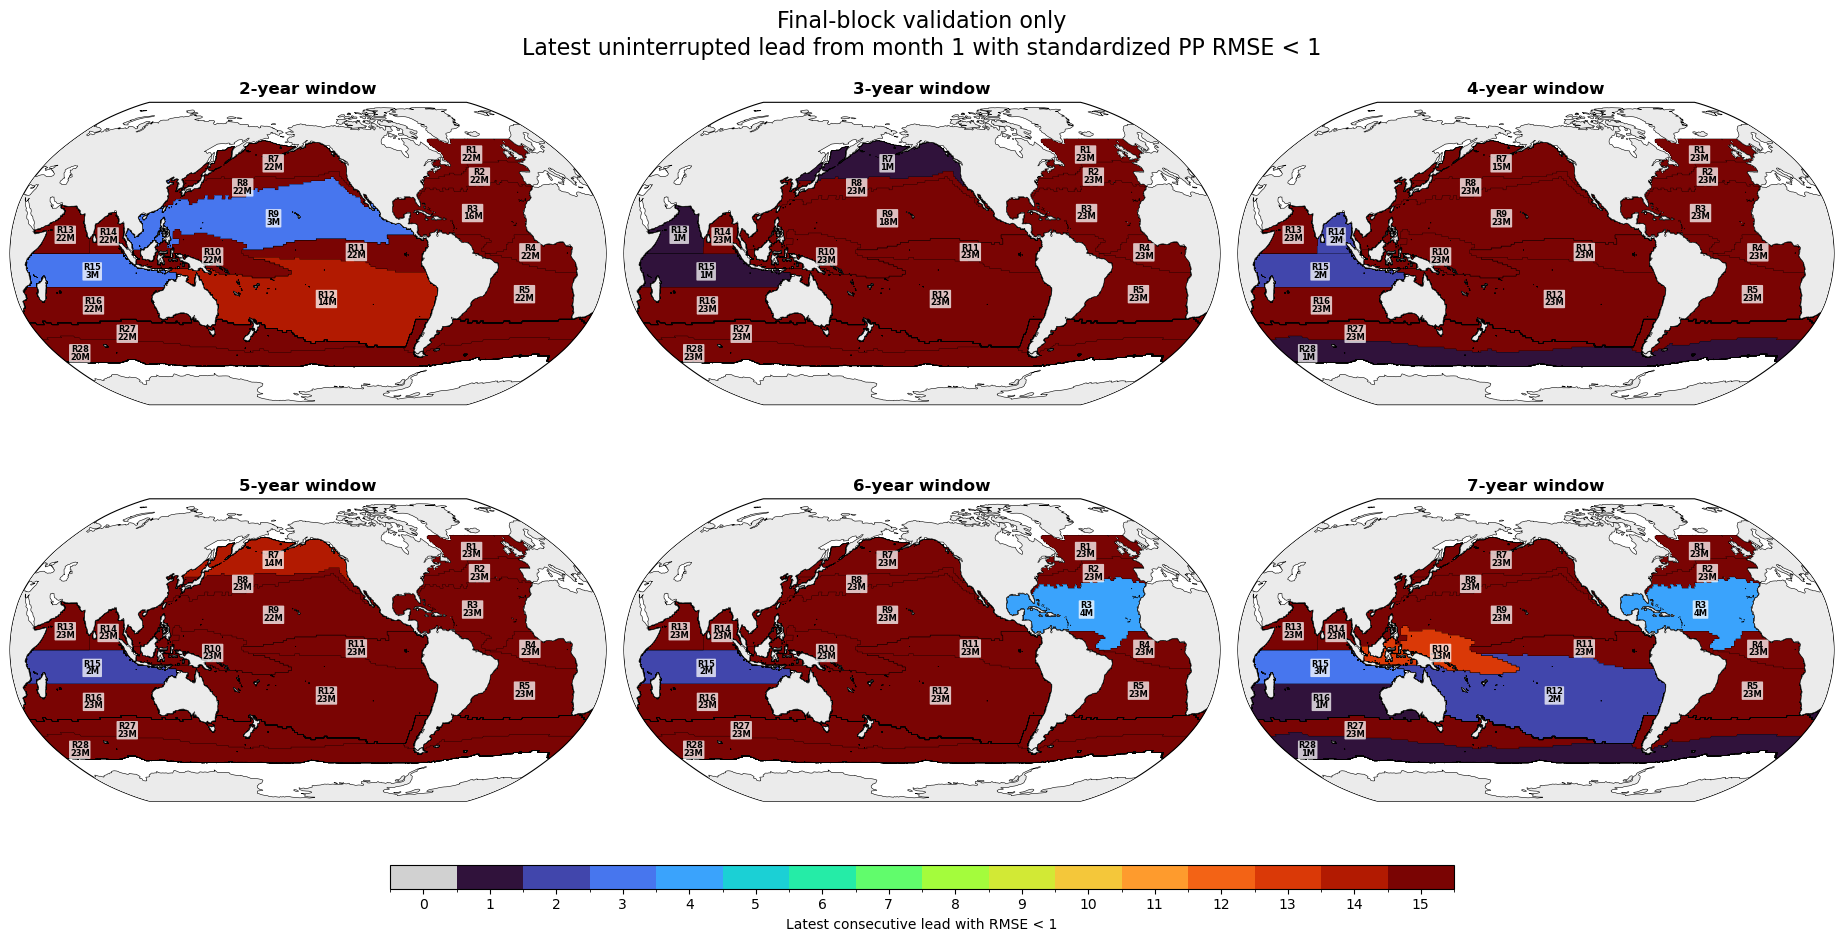

In [7]:

# ============================================================
# 6. Global maps: latest contiguous lead with RMSE < 1
# ============================================================

if not VALID_MASK_FILE.exists():
    raise FileNotFoundError(
        f"Mask file not found:\n{VALID_MASK_FILE}"
    )

with xr.open_dataset(VALID_MASK_FILE) as ds:
    ds_mask = ds.load()

mask = ds_mask["valid_region_mask"]
lat = ds_mask.latitude.values.astype(float)
lon = ds_mask.longitude.values.astype(float)
mask_values = mask.values.astype(np.int16)

mask_plot_full = mask_values.copy()
for reg_ex in EXCLUDE_REGIONS:
    mask_plot_full[mask_plot_full == reg_ex] = 0

mask_region_set = set(
    np.unique(
        mask_plot_full[mask_plot_full > 0]
    ).astype(int)
)

remaining_regions = np.unique(
    mask_plot_full[mask_plot_full > 0]
)
boundary_levels = np.arange(
    0.5,
    int(np.nanmax(remaining_regions)) + 1.5,
    1.0,
)

bounds = np.arange(
    -0.5,
    DISPLAY_MAX_LEAD + 1.5,
    1.0,
)

try:
    base = plt.get_cmap("turbo", DISPLAY_MAX_LEAD)
except ValueError:
    base = plt.get_cmap("plasma", DISPLAY_MAX_LEAD)

colors = (
    [(0.82, 0.82, 0.82, 1.0)]
    + [base(i) for i in range(DISPLAY_MAX_LEAD)]
)
cmap = ListedColormap(colors)
cmap.set_bad((1, 1, 1, 0))
norm = BoundaryNorm(bounds, cmap.N)


for design, design_title in [
    ("moving_cv", "Moving blocked cross-validation"),
    ("last_block", "Final-block validation only"),
]:
    fig, axes = plt.subplots(
        2,
        3,
        figsize=(19, 9.5),
        subplot_kw={
            "projection": ccrs.Robinson(
                central_longitude=CENTRAL_LONGITUDE
            )
        },
    )
    axes = axes.ravel()

    last_im = None

    for ax, window_years in zip(axes, WINDOW_YEARS):
        window_years = int(window_years)
        ds_this = rmse_datasets[design][window_years]

        latest = ds_this[
            "latest_contiguous_lead_rmse_lt_1"
        ]

        regions_to_plot = [
            int(reg)
            for reg in latest.region.values
            if (
                int(reg) not in EXCLUDE_REGIONS
                and int(reg) in mask_region_set
            )
        ]
        latest_plot = latest.sel(region=regions_to_plot)

        lead_map = np.full(
            mask_values.shape,
            np.nan,
            dtype=np.float32,
        )

        for reg in latest_plot.region.values:
            reg = int(reg)
            lead_map[
                mask_plot_full == reg
            ] = float(
                latest_plot.sel(region=reg).values
            )

        lead_map = np.where(
            mask_plot_full > 0,
            lead_map,
            np.nan,
        )

        lat_plot = lat[::PLOT_STRIDE]
        lon_plot = lon[::PLOT_STRIDE]
        lead_plot = lead_map[
            ::PLOT_STRIDE,
            ::PLOT_STRIDE,
        ]
        mask_plot = mask_plot_full[
            ::PLOT_STRIDE,
            ::PLOT_STRIDE,
        ].astype(float)

        lead_cyc, lon_cyc = add_cyclic_manual(
            lead_plot,
            lon_plot,
        )
        mask_cyc, _ = add_cyclic_manual(
            mask_plot,
            lon_plot,
        )

        lead_cyc_plot = np.where(
            np.isfinite(lead_cyc),
            np.minimum(lead_cyc, DISPLAY_MAX_LEAD),
            np.nan,
        )

        last_im = ax.pcolormesh(
            lon_cyc,
            lat_plot,
            lead_cyc_plot,
            cmap=cmap,
            norm=norm,
            shading="auto",
            transform=ccrs.PlateCarree(),
        )

        ax.contour(
            lon_cyc,
            lat_plot,
            mask_cyc,
            levels=boundary_levels,
            colors="k",
            linewidths=0.25,
            transform=ccrs.PlateCarree(),
        )

        ax.add_feature(
            cfeature.LAND,
            facecolor="0.92",
            edgecolor="none",
            zorder=3,
        )
        ax.coastlines(linewidth=0.4, zorder=4)
        ax.set_global()

        for reg in latest_plot.region.values:
            reg = int(reg)
            region_mask = mask_plot_full == reg
            if not np.any(region_mask):
                continue

            lon_c, lat_c = weighted_centroid(
                lon,
                lat,
                region_mask,
            )
            if not (
                np.isfinite(lon_c)
                and np.isfinite(lat_c)
            ):
                continue

            value = int(
                latest_plot.sel(region=reg).values
            )

            ax.text(
                lon_to_180(lon_c),
                lat_c,
                f"R{reg}\n{value}M",
                transform=ccrs.PlateCarree(),
                ha="center",
                va="center",
                fontsize=6.0,
                fontweight="bold",
                linespacing=0.82,
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.75,
                    boxstyle="round,pad=0.10",
                ),
                zorder=5,
            )

        ax.set_title(
            f"{window_years}-year window",
            fontsize=12,
            fontweight="bold",
        )

    fig.suptitle(
        f"{design_title}\n"
        "Latest uninterrupted lead from month 1 with standardized PP RMSE < 1",
        fontsize=16,
        y=0.98,
    )

    fig.subplots_adjust(
        left=0.02,
        right=0.98,
        top=0.91,
        bottom=0.12,
        wspace=0.03,
        hspace=0.12,
    )

    cax = fig.add_axes([0.22, 0.055, 0.56, 0.025])
    cbar = fig.colorbar(
        last_im,
        cax=cax,
        orientation="horizontal",
        ticks=np.arange(
            0,
            DISPLAY_MAX_LEAD + 1,
            1,
        ),
        boundaries=bounds,
    )
    cbar.set_label(
        "Latest consecutive lead with RMSE < 1"
    )

    if SAVE_FIGURES:
        fig.savefig(
            FIG_DIR / f"RMSE_latest_contiguous_map_{design}_2to7year.png",
            dpi=200,
            bbox_inches="tight",
        )

    plt.show()


In [8]:

# ============================================================
# 7. Compact summary table
# ============================================================

rows = []

for design in ["moving_cv", "last_block"]:
    for window_years in WINDOW_YEARS:
        window_years = int(window_years)
        ds_this = rmse_datasets[design][window_years]

        latest = ds_this[
            "latest_contiguous_lead_rmse_lt_1"
        ].values.astype(float)

        rmse_all = ds_this["PP_RMSE"].values.astype(float)

        rows.append({
            "design": design,
            "window_years": window_years,
            "median_latest_contiguous_lead": float(
                np.nanmedian(latest)
            ),
            "mean_latest_contiguous_lead": float(
                np.nanmean(latest)
            ),
            "median_RMSE_all_regions_leads": float(
                np.nanmedian(rmse_all)
            ),
            "fraction_region_leads_RMSE_lt_1": float(
                np.nanmean(rmse_all < RMSE_THRESHOLD)
            ),
        })

summary = pd.DataFrame(rows)
summary


,design,window_years,median_latest_contiguous_lead,mean_latest_contiguous_lead,median_RMSE_all_regions_leads,fraction_region_leads_RMSE_lt_1
0,moving_cv,2,23.0,23.000000,0.805611,1.000000
1,moving_cv,3,23.0,23.000000,0.804205,1.000000
2,moving_cv,4,23.0,23.000000,0.809089,1.000000
3,moving_cv,5,23.0,22.476190,0.811295,0.985507
4,moving_cv,6,23.0,21.952381,0.801946,0.995859
5,moving_cv,7,23.0,20.904762,0.812803,0.995859
6,last_block,2,22.0,17.809524,0.667831,0.842650
7,last_block,3,23.0,18.476190,0.707458,0.908903
8,last_block,4,23.0,18.523810,0.749883,0.915114
9,last_block,5,23.0,21.523810,0.740930,0.944099
